In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from sklearn.linear_model import LinearRegression

df = pd.read_csv('../data/cleaned/clean_sales.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
print("Data loaded successfully!")

Data loaded successfully!


In [2]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales = monthly_sales.reset_index()
monthly_sales.columns = ['Date', 'Sales']
monthly_sales['Month_Num'] = np.arange(len(monthly_sales))

print(f"Total months of data: {len(monthly_sales)}")
print(monthly_sales.tail())

Total months of data: 48
         Date        Sales  Month_Num
43 2018-08-01   62837.8480         43
44 2018-09-01   86152.8880         44
45 2018-10-01   77448.1312         45
46 2018-11-01  117938.1550         46
47 2018-12-01   83030.3888         47


In [3]:
X = monthly_sales[['Month_Num']]
y = monthly_sales['Sales']

model = LinearRegression()
model.fit(X, y)

print(f"Model trained successfully!")
print(f"Monthly growth trend: ${model.coef_[0]:,.0f} per month")

Model trained successfully!
Monthly growth trend: $888 per month


In [4]:
last_month = monthly_sales['Date'].max()
future_dates = pd.date_range(start=last_month, periods=7, freq='ME')[1:]
future_month_nums = np.arange(len(monthly_sales), len(monthly_sales) + 6).reshape(-1, 1)
future_sales = model.predict(future_month_nums)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted Sales': future_sales
})

print("Forecast for next 6 months:")
print(forecast_df.to_string(index=False))

Forecast for next 6 months:
      Date  Forecasted Sales
2019-01-31      68878.998333
2019-02-28      69767.310525
2019-03-31      70655.622716
2019-04-30      71543.934908
2019-05-31      72432.247100
2019-06-30      73320.559291


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


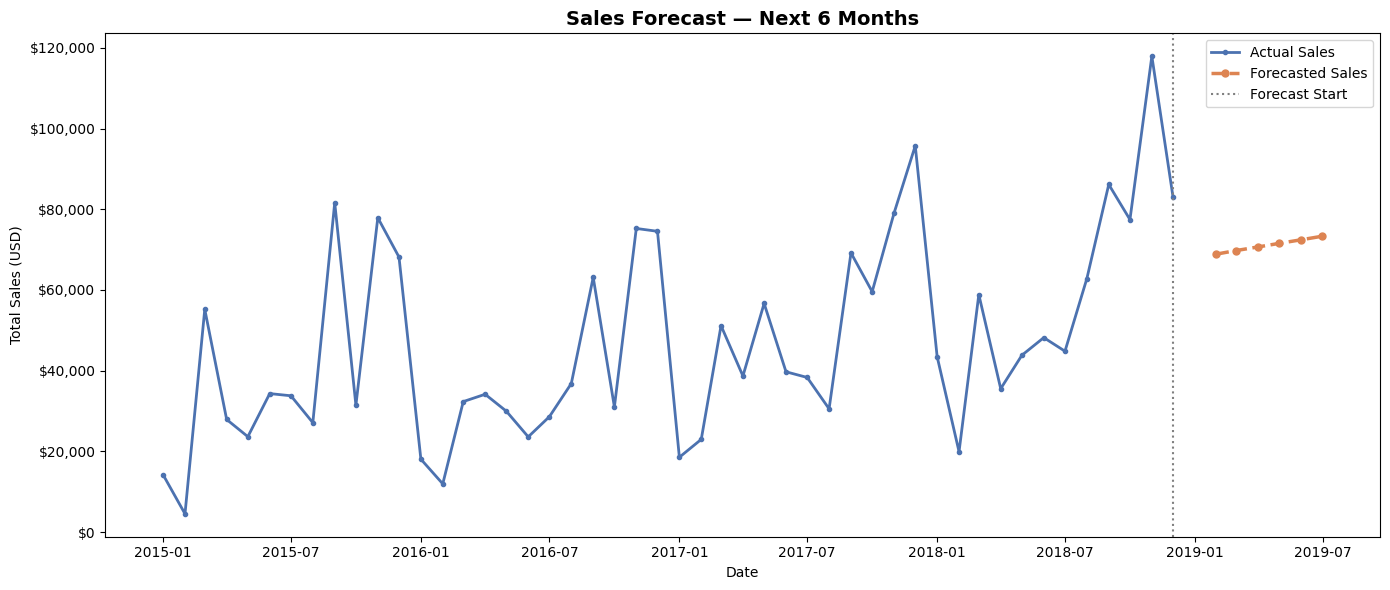

Forecast chart saved!


In [5]:
plt.figure(figsize=(14, 6))

plt.plot(monthly_sales['Date'], monthly_sales['Sales'],
         color='#4C72B0', linewidth=2, label='Actual Sales', marker='o', markersize=3)

plt.plot(forecast_df['Date'], forecast_df['Forecasted Sales'],
         color='#DD8452', linewidth=2.5, linestyle='--',
         label='Forecasted Sales', marker='o', markersize=5)

plt.axvline(x=monthly_sales['Date'].max(), color='gray',
            linestyle=':', linewidth=1.5, label='Forecast Start')

plt.title('Sales Forecast — Next 6 Months', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales (USD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.savefig('../visualizations/05_sales_forecast.png', dpi=150)
plt.show()
print("Forecast chart saved!")